In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [ ]:
pd.set_option( 'display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [ ]:
''' index - Unique Identifier for each row
    transdatetrans_time - Transaction DateTime
    cc_num - Credit Card Number of Customer
    merchant - Merchant Name
    category - Category of Merchant
    amt - Amount of Transaction
    first - First Name of Credit Card Holder
    last - Last Name of Credit Card Holder
    gender - Gender of Credit Card Holder
    street - Street Address of Credit Card Holder
    city - City of Credit Card Holder
    state - State of Credit Card Holder
    zip - Zip of Credit Card Holder
    lat - Latitude Location of Credit Card Holder
    long - Longitude Location of Credit Card Holder
    city_pop - Credit Card Holder's City Population
    job - Job of Credit Card Holder
    dob - Date of Birth of Credit Card Holder
    trans_num - Transaction Number
    unix_time - UNIX Time of transaction
    merch_lat - Latitude Location of Merchant
    merch_long - Longitude Location of Merchant
    is_fraud - Fraud Flag <--- Target Class'''

" index - Unique Identifier for each row\n    transdatetrans_time - Transaction DateTime\n    cc_num - Credit Card Number of Customer\n    merchant - Merchant Name\n    category - Category of Merchant\n    amt - Amount of Transaction\n    first - First Name of Credit Card Holder\n    last - Last Name of Credit Card Holder\n    gender - Gender of Credit Card Holder\n    street - Street Address of Credit Card Holder\n    city - City of Credit Card Holder\n    state - State of Credit Card Holder\n    zip - Zip of Credit Card Holder\n    lat - Latitude Location of Credit Card Holder\n    long - Longitude Location of Credit Card Holder\n    city_pop - Credit Card Holder's City Population\n    job - Job of Credit Card Holder\n    dob - Date of Birth of Credit Card Holder\n    trans_num - Transaction Number\n    unix_time - UNIX Time of transaction\n    merch_lat - Latitude Location of Merchant\n    merch_long - Longitude Location of Merchant\n    is_fraud - Fraud Flag <--- Target Class"

 - Crear una TAD que me ayude a construir un modelo de ML de clasificación binaria para identificar si una transacción es fraudulenta o no.

In [ ]:
df = pd.read_csv('fraud/fraudTrain.csv')

In [ ]:
df.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0


In [ ]:
# Si es posible porque se tiene la TARGET o variable objetivo
df['is_fraud'].value_counts(True)*100

is_fraud
0   99.4211
1    0.5789
Name: proportion, dtype: float64

# Exploración / Limpieza / Inspección

In [ ]:
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [ ]:
for c in df.columns:
    print(c, df[c].map(type).unique().tolist() )

Unnamed: 0 [<class 'int'>]
trans_date_trans_time [<class 'str'>]
cc_num [<class 'int'>]
merchant [<class 'str'>]
category [<class 'str'>]
amt [<class 'float'>]
first [<class 'str'>]
last [<class 'str'>]
gender [<class 'str'>]
street [<class 'str'>]
city [<class 'str'>]
state [<class 'str'>]
zip [<class 'int'>]
lat [<class 'float'>]
long [<class 'float'>]
city_pop [<class 'int'>]
job [<class 'str'>]
dob [<class 'str'>]
trans_num [<class 'str'>]
unix_time [<class 'int'>]
merch_lat [<class 'float'>]
merch_long [<class 'float'>]
is_fraud [<class 'int'>]


In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.5600,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.8413,-111.6908,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.7000,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.9069,-78.2465,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.9300,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.6195,-105.1305,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.9000,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.7889,-103.2412,0


In [ ]:
df.describe(percentiles=np.arange(0.01,1,0.01))

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000,1296675.0000
mean,417192042079726656.0000,70.3510,48800.6711,38.5376,-90.2263,88824.4406,1349243636.7261,38.5373,-90.2265,0.0058
std,1308806447000240384.0000,160.3160,26893.2225,5.0758,13.7591,301956.3607,12841278.4234,5.1098,13.7711,0.0759
min,60416207185.0000,1.0000,1257.0000,20.0271,-165.6723,23.0000,1325376018.0000,19.0278,-166.6712,0.0000
1%,502012776709.0000,1.2600,3220.0000,26.4722,-123.0614,53.0000,1326022167.7400,26.3894,-123.5620,0.0000
...,...,...,...,...,...,...,...,...,...,...
96%,4584931703207308288.0000,214.4600,95629.0000,46.3535,-73.0980,687276.0000,1370179651.4400,46.5021,-72.9707,0.0000
97%,4710826438164847616.0000,248.0678,97014.0000,47.1709,-72.4439,910148.0000,1370627183.9200,47.0855,-72.3581,0.0000
98%,4792627764422477824.0000,337.9800,97452.0000,47.7068,-71.2551,1263321.0000,1370996426.7600,47.8340,-71.5085,0.0000
99%,4890424426862857216.0000,545.9926,98304.0000,48.4786,-70.3457,1577385.0000,1371363386.0400,48.5779,-70.3850,0.0000


In [ ]:
print(f"{df['gender'].value_counts(True,dropna=False)*100}\n")
print(f"{df['category'].value_counts(True,dropna=False)*100}\n")
print(f"{df['merchant'].value_counts(True,dropna=False)*100}\n")
print(f"{df['state'].value_counts(True,dropna=False)*100}\n")
print(f"{df['job'].value_counts(True,dropna=False)*100}\n")
print(f"{df['dob'].value_counts(True,dropna=False)*100}\n")


gender
F   54.7449
M   45.2551
Name: proportion, dtype: float64

category
gas_transport    10.1536
grocery_pos       9.5350
home              9.4947
shopping_pos      8.9978
kids_pets         8.7173
shopping_net      7.5225
entertainment     7.2504
food_dining       7.0535
personal_care     6.9993
health_fitness    6.6230
misc_pos          6.1430
misc_net          4.8807
grocery_net       3.5053
travel            3.1239
Name: proportion, dtype: float64

merchant
fraud_Kilback LLC                      0.3396
fraud_Cormier LLC                      0.2814
fraud_Schumm PLC                       0.2803
fraud_Kuhn LLC                         0.2707
fraud_Boyer PLC                        0.2694
                                        ...  
fraud_Douglas, DuBuque and McKenzie    0.0598
fraud_Treutel-King                     0.0598
fraud_Medhurst, Labadie and Gottlieb   0.0585
fraud_Reichert-Weissnat                0.0581
fraud_Hahn, Douglas and Schowalter     0.0561
Name: proportion, Length: 6

<Axes: >

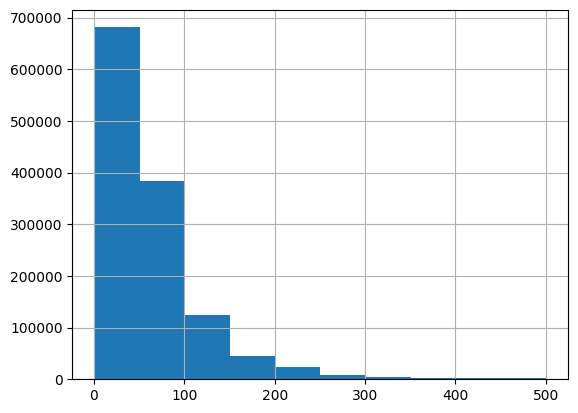

In [ ]:
df[df['amt'] < 500]['amt'].hist()

In [ ]:
df.head(1)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0


In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='%Y-%m-%d %H:%M:%S')

In [ ]:
df['dob'] = pd.to_datetime(df['dob'], format='%Y-%m-%d')

In [ ]:
df['zip'] = df['zip'].apply(lambda x: str(x).zfill(5) )

In [ ]:
df.dtypes

trans_date_trans_time    datetime64[us]
cc_num                            int64
merchant                            str
category                            str
amt                             float64
first                               str
last                                str
gender                              str
street                              str
city                                str
state                               str
zip                                 str
lat                             float64
long                            float64
city_pop                          int64
job                                 str
dob                      datetime64[us]
trans_num                           str
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
dtype: object

In [ ]:
df['trans_date_trans_time'].min() , df['trans_date_trans_time'].max()

(Timestamp('2019-01-01 00:00:18'), Timestamp('2020-06-21 12:13:37'))

In [ ]:
df['dob'].min() , df['dob'].max()

(Timestamp('1924-10-30 00:00:00'), Timestamp('2005-01-29 00:00:00'))

In [ ]:
df.shape

(1296675, 22)

# Ingeniería de variables

- Edad al momento de la transacción
- Acumulado de transacciones al momento de la transacción
- Promedio/max,min,count,  del monto de las transacciones previas a la transacción (de ser posible mensual)
- Total de transacciones recientes previas a la transacción
- Promedio de las transacciones por comercio/mes/...  previo a la transacción
- Distancia entre las latitudes y longitudes
- Día de la semana de la transacción
- Mes de la transacción
- Hora
- Etapas del día
- Tiempo entre transacción previa de la misma tarjeta

- ** Validar los fraudes por trajeta y cliente **  

In [ ]:
# Variables de fecha y hora
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['month_desc'] = df['month'].map({1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'})

df['dayofweek'] = df['trans_date_trans_time'].dt.dayofweek
df['dayofweek_desc'] = df['dayofweek'].map({0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'})


df['dayofyear'] = df['trans_date_trans_time'].dt.dayofyear
df['weekofyear'] = df['trans_date_trans_time'].dt.isocalendar().week

df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

df['trans_num'] = df.groupby('cc_num')['trans_num'].cumcount() + 1

df['prev_trans_amt'] = df.groupby('cc_num')['amt'].shift(1)

df['prev_trans_count'] = df.groupby('cc_num')['trans_num'].shift(1)

df['prev_trans_mean'] = df.groupby('cc_num')['amt'].shift(1).rolling(window=10).mean()

df['prev_trans_max'] = df.groupby('cc_num')['amt'].shift(1).rolling(window=10).max()

df['prev_trans_min'] = df.groupby('cc_num')['amt'].shift(1).rolling(window=10).min()

df['dist_lat_long'] = np.sqrt((df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2)

In [ ]:
df['ratio_amt_age'] = df['amt']/df['age']
df['ratio_amt_trans_num'] = df['amt']/df['prev_trans_count']
df['ratio_amt_prev_trans_amt'] = df['amt']/df['prev_trans_amt']
df['ratio_amt_prev_trans_mean'] = df['amt']/df['prev_trans_mean']
df['ratio_amt_prev_trans_max'] = df['amt']/df['prev_trans_max']
df['ratio_amt_prev_trans_min'] = df['amt']/df['prev_trans_min']

df['ratio_amt_dist_lat_long'] = df['amt']/df['dist_lat_long']

In [ ]:
def etapa_del_dia(hora):
    if hora >= 0 and hora < 6:
        return 'madrugada'
    elif hora >= 6 and hora < 12:
        return 'mañana'
    elif hora >= 12 and hora < 18:
        return 'tarde'
    elif hora >= 18 and hora < 24:
        return 'noche'
    else:
        return 'error'

In [ ]:
df['etapa_del_dia'] = df['hour'].apply(etapa_del_dia)

In [ ]:
df.sample(10)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,month_desc,dayofweek,dayofweek_desc,dayofyear,weekofyear,age,prev_trans_amt,prev_trans_count,prev_trans_mean,prev_trans_max,prev_trans_min,dist_lat_long,ratio_amt_age,ratio_amt_trans_num,ratio_amt_prev_trans_amt,ratio_amt_prev_trans_mean,ratio_amt_prev_trans_max,ratio_amt_prev_trans_min,ratio_amt_dist_lat_long,etapa_del_dia
860269,2019-12-17 09:22:41,4957924165498,fraud_Schmeler Inc,misc_pos,5.4500,Alan,Parsons,M,0547 Russell Ford Suite 574,Kirk,CO,80824,39.6171,-102.4776,207,Network engineer,1955-12-04,684,1355736161,40.1222,-102.1111,0,9,17,12,Diciembre,1,Martes,351,51,64,1.8400,683.0000,163.4860,888.8600,1.8400,0.6241,0.0852,0.0080,2.9620,0.0333,0.0061,2.9620,8.7323,mañana
754370,2019-11-18 14:50:38,213126662687660,"fraud_Metz, Russel and Metz",kids_pets,22.7600,Christopher,Luna,M,242 Brian Mountain,Laredo,TX,78040,27.5155,-99.4986,248858,Video editor,1971-01-28,874,1353250238,28.2202,-99.0027,0,14,18,11,Noviembre,0,Lunes,322,47,48,45.6700,873.0000,36.4150,103.7100,2.2300,0.8617,0.4742,0.0261,0.4984,0.6250,0.2195,10.2063,26.4116,tarde
724801,2019-11-05 11:18:10,4149238353975790,fraud_Cartwright-Harris,grocery_pos,97.6100,Tanner,Carroll,M,494 Burke Ports,Cokeburg,PA,15324,40.1008,-80.0652,632,Dealer,1989-04-08,1182,1352114290,40.7439,-79.1667,0,11,5,11,Noviembre,1,Martes,309,45,30,41.8900,1181.0000,75.2470,337.2400,4.8400,1.1050,3.2537,0.0827,2.3302,1.2972,0.2894,20.1674,88.3376,mañana
906862,2019-12-28 14:20:23,3561963695236764,fraud_Pouros-Haag,shopping_pos,124.6600,Michael,Lee,M,7915 Dawn Roads Apt. 544,Shelter Island,NY,11964,41.0640,-72.3366,1858,Clinical biochemist,1984-03-03,1084,1356704423,40.9517,-72.8222,0,14,28,12,Diciembre,5,Sábado,362,52,35,93.9000,1083.0000,48.2570,109.3900,2.3100,0.4984,3.5617,0.1151,1.3276,2.5833,1.1396,53.9654,250.1085,tarde
834145,2019-12-12 00:07:56,180031190491743,"fraud_Turner, Ruecker and Parisian",misc_pos,149.7700,Becky,Mckinney,F,250 Benjamin Hill Apt. 026,Mobile,AL,36617,30.7145,-88.0918,270712,"Surveyor, land/geomatics",1972-01-05,1667,1355270876,31.6260,-87.2493,0,0,12,12,Diciembre,3,Jueves,346,50,47,41.5600,1666.0000,59.7470,139.7000,8.4100,1.2412,3.1866,0.0899,3.6037,2.5067,1.0721,17.8086,120.6644,madrugada
901890,2019-12-27 12:26:10,213161869125933,fraud_Schoen-Quigley,kids_pets,62.1100,Monica,Lane,F,3270 Scott Islands,East Andover,ME,04226,44.6084,-70.6993,190,Animal nutritionist,1970-04-17,1113,1356611170,44.4829,-70.4617,0,12,27,12,Diciembre,4,Viernes,361,52,49,6.0500,1112.0000,66.4720,189.3800,3.6300,0.2687,1.2676,0.0559,10.2661,0.9344,0.3280,17.1102,231.1724,tarde
101282,2019-02-28 12:22:42,4169759661243568,fraud_Towne LLC,misc_pos,19.3000,Jamie,Carr,F,55363 Aaron Circle Suite 450,Lawn,PA,17041,40.2236,-76.5380,213,Special educational needs teacher,1972-02-15,137,1330518162,39.7249,-76.0207,0,12,28,2,Febrero,3,Jueves,59,9,47,124.2700,136.0000,83.4130,246.8700,6.8800,0.7186,0.4106,0.1419,0.1553,0.2314,0.0782,2.8052,26.8593,tarde
657073,2019-10-06 21:23:37,6547670341037171,fraud_Bednar PLC,kids_pets,55.7200,Bryce,Joseph,M,148 Baker Field,Chester Heights,PA,19017,39.8839,-75.4669,348,Management consultant,1945-05-05,784,1349558617,40.3549,-75.3842,0,21,6,10,Octubre,6,Domingo,279,40,74,64.6300,783.0000,31.7360,68.9700,4.8500,0.4782,0.7530,0.0712,0.8621,1.7557,0.8079,11.4887,116.5264,noche
628747,2019-09-23 23:32:08,4457732997086323466,fraud_Rempel Inc,shopping_net,1214.3900,Stanley,Mayo,M,3433 Jones Branch,Fiddletown,CA,95629,38.5234,-120.6763,832,Immigration officer,1987-05-19,1011,1348443128,38.8280,-119.7821,1,23,23,9,Septiembre,0,Lunes,266,39,32,855.2800,1010.0000,253.7020,884.0800,5.6900,0.9447,37.9497,1.2024,1.4199,4.7867,1.3736,213.4253,1285.4906,noche
231347,2019-04-27 05:08:43,4247921790666,"fraud_Hagenes, Kohler and Hoppe",food_dining,60.1300,Judith,Moss,F,46297 Benjamin Plains Suite 703

# Tipo de variables

- c_ ->  categoricas / discretas
- v_ ->  continuas   / numéricas
- fh_ -> fechas
- bl_ -> booleanas

In [ ]:
df = df.reset_index()

In [ ]:
df.head(2)

,index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,month_desc,dayofweek,dayofweek_desc,dayofyear,weekofyear,age,prev_trans_amt,prev_trans_count,prev_trans_mean,prev_trans_max,prev_trans_min,dist_lat_long,ratio_amt_age,ratio_amt_trans_num,ratio_amt_prev_trans_amt,ratio_amt_prev_trans_mean,ratio_amt_prev_trans_max,ratio_amt_prev_trans_min,ratio_amt_dist_lat_long,etapa_del_dia
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,1,1325376018,36.0113,-82.0483,0,0,1,1,Enero,1,Martes,1,1,31,NaN,NaN,NaN,NaN,NaN,0.8728,0.1603,NaN,NaN,NaN,NaN,NaN,5.6941,madrugada
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1,1325376044,49.1590,-118.1865,0,0,1,1,Enero,1,Martes,1,1,41,NaN,NaN,NaN,NaN,NaN,0.2723,2.6154,NaN,NaN,NaN,NaN,NaN,393.7791,madrugada


In [ ]:
# Unidad muestra
um = ['index']

# Variables objetivo o Target
tgt = ['is_fraud']

# Categóricas / Discretas
vard = [ 'merchant','category','first','last','gender','street','city','state','zip','job', 'trans_num', 'hour','day',
'month','month_desc' , 'hour','day','month','month_desc','dayofweek','dayofweek_desc','dayofyear','etapa_del_dia']

# Numéricas / Continuas
varc = ['amt','lat','long','city_pop', 'unix_time' , 'merch_lat','merch_long', 'age',
'prev_trans_amt','prev_trans_count','prev_trans_mean','prev_trans_max',
'prev_trans_min','dist_lat_long','ratio_amt_age','ratio_amt_trans_num','ratio_amt_prev_trans_amt','ratio_amt_prev_trans_mean',
'ratio_amt_prev_trans_max','ratio_amt_prev_trans_min','ratio_amt_dist_lat_long']

varfh = ['dob','trans_date_trans_time']

In [ ]:
df.dtypes

index                                 int64
trans_date_trans_time        datetime64[us]
cc_num                                int64
merchant                                str
category                                str
amt                                 float64
first                                   str
last                                    str
gender                                  str
street                                  str
city                                    str
state                                   str
zip                                     str
lat                                 float64
long                                float64
city_pop                              int64
job                                     str
dob                          datetime64[us]
trans_num                             int64
unix_time                             int64
merch_lat                           float64
merch_long                          float64
is_fraud                        

In [ ]:
df.rename(columns={c:'v_'+c for c in varc}, inplace=True)
df.rename(columns={c:'c_'+c for c in vard}, inplace=True)

In [ ]:
df.sample(3)

,index,trans_date_trans_time,cc_num,c_merchant,c_category,v_amt,c_first,c_last,c_gender,c_street,c_city,c_state,c_zip,v_lat,v_long,v_city_pop,c_job,dob,c_trans_num,v_unix_time,v_merch_lat,v_merch_long,is_fraud,c_hour,c_day,c_month,c_month_desc,c_dayofweek,c_dayofweek_desc,c_dayofyear,weekofyear,v_age,v_prev_trans_amt,v_prev_trans_count,v_prev_trans_mean,v_prev_trans_max,v_prev_trans_min,v_dist_lat_long,v_ratio_amt_age,v_ratio_amt_trans_num,v_ratio_amt_prev_trans_amt,v_ratio_amt_prev_trans_mean,v_ratio_amt_prev_trans_max,v_ratio_amt_prev_trans_min,v_ratio_amt_dist_lat_long,c_etapa_del_dia
234844,234844,2019-04-28 12:22:54,213173753804333,fraud_Prosacco LLC,personal_care,4.5800,Joseph,Wagner,M,822 Austin Spur,North Judson,IN,46366,41.2244,-86.6966,5791,"Doctor, general practice",1959-10-07,279,1335615774,42.1402,-86.1488,0,12,28,4,Abril,6,Domingo,118,17,60,1.2800,278.0000,106.1340,449.9500,1.2800,1.0672,0.0763,0.0165,3.5781,0.0432,0.0102,3.5781,4.2918,tarde
654078,654078,2019-10-05 22:26:27,3540862542587229,"fraud_Bernhard, Grant and Langworth",shopping_pos,816.0100,Nancy,Roach,F,376 Brown Courts,Yellowstone National Park,WY,82190,44.7957,-110.6137,369,Materials engineer,1941-11-16,250,1349475987,44.4188,-111.0243,1,22,5,10,Octubre,5,Sábado,278,40,78,328.7200,249.0000,123.8850,719.8800,5.3100,0.5574,10.4617,3.2771,2.4824,6.5868,1.1335,153.6742,1464.0167,noche
740642,740642,2019-11-12 13:21:29,4562827002127,"fraud_O'Connell, Botsford and Hand",home,34.5800,Christopher,Johnson,M,28711 Kristine Junction Suite 309,Greenville,OH,45331,40.0987,-84.6342,22930,Media planner,1971-11-26,608,1352726489,39.4341,-84.4766,0,13,12,11,Noviembre,1,Martes,316,46,48,53.8500,607.0000,79.3300,200.0100,2.8400,0.6830,0.7204,0.0570,0.6422,0.4359,0.1729,12.1761,50.6300,tarde


In [ ]:
varc = df.filter(like='v_').columns.tolist()
vard = df.filter(like='c_').columns.tolist()

In [ ]:
len(varc), len(vard)

(21, 20)

In [ ]:
for col in varc:
    df[col] = pd.to_numeric(df[col], errors='coerce') # Convierte a numérico y ponen NaNs

for col in vard:
    df[col] = df[col].astype(str)


In [ ]:
df.dtypes

index                                   int64
trans_date_trans_time          datetime64[us]
cc_num                                    str
c_merchant                                str
c_category                                str
v_amt                                 float64
c_first                                   str
c_last                                    str
c_gender                                  str
c_street                                  str
c_city                                    str
c_state                                   str
c_zip                                     str
v_lat                                 float64
v_long                                float64
v_city_pop                              int64
c_job                                     str
dob                            datetime64[us]
c_trans_num                               str
v_unix_time                             int64
v_merch_lat                           float64
v_merch_long                      

# Análisis exploratorio     

## Discreto / Categorico

In [ ]:
def freq(df, var):

    if type(var) != list:
        var = [var]
    for v in var:
        #v = 'state'
        aux = df[v].value_counts().to_frame().rename(columns={'count':'FA'})
        aux['FR'] = aux['FA'] / aux['FA'].sum()
        aux[['FAA','FRA']] = aux.apply(  np.cumsum )
        print(f"La variable: {v}")
        display(aux)
        print("\n")

def normalizar(df, v, umbral):
    #umbral = 0.03 # 0.05
    aux = df[v].value_counts(True).to_frame()
    aux[f"n_{v}"] = np.where( aux['proportion'] < umbral , 'CAT_PEQUE' ,aux.index )

    moda  = aux.head()[f'n_{v}'].values[0]

    if aux.loc[ aux[f'n_{v}'] == 'CAT_PEQUE' ]['proportion'].sum() < umbral:
        aux[f'n_{v}'].replace({'CAT_PEQUE':moda},inplace=True)

    aux.reset_index(inplace=True)

    return df.merge( aux , left_on=[v] , right_on=[v] , how='inner' ).drop('proportion',axis=1)

### Análisis de frecuencias

In [ ]:
freq( df , vard )

La variable: cc_num


,FA,FR,FAA,FRA
cc_num,,,,
4512828414983801773,3123,0.0024,3123,0.0024
571365235126,3123,0.0024,6246,0.0048
36722699017270,3119,0.0024,9365,0.0072
213112402583773,3117,0.0024,12482,0.0096
3545109339866548,3113,0.0024,15595,0.0120
...,...,...,...,...
501894933032,7,0.0000,1296647,1.0000
4975457191020,7,0.0000,1296654,1.0000
6577777028615915,7,0.0000,1296661,1.0000




La variable: c_merchant


,FA,FR,FAA,FRA
c_merchant,,,,
fraud_Kilback LLC,4403,0.0034,4403,0.0034
fraud_Cormier LLC,3649,0.0028,8052,0.0062
fraud_Schumm PLC,3634,0.0028,11686,0.0090
fraud_Kuhn LLC,3510,0.0027,15196,0.0117
fraud_Boyer PLC,3493,0.0027,18689,0.0144
...,...,...,...,...
"fraud_Douglas, DuBuque and McKenzie",775,0.0006,1293661,0.9977
fraud_Treutel-King,775,0.0006,1294436,0.9983
"fraud_Medhurst, Labadie and Gottlieb",759,0.0006,1295195,0.9989




La variable: c_category


,FA,FR,FAA,FRA
c_category,,,,
gas_transport,131659,0.1015,131659,0.1015
grocery_pos,123638,0.0954,255297,0.1969
home,123115,0.0949,378412,0.2918
shopping_pos,116672,0.0900,495084,0.3818
kids_pets,113035,0.0872,608119,0.4690
shopping_net,97543,0.0752,705662,0.5442
entertainment,94014,0.0725,799676,0.6167
food_dining,91461,0.0705,891137,0.6872
personal_care,90758,0.0700,981895,0.7572




La variable: c_first


,FA,FR,FAA,FRA
c_first,,,,
Christopher,26669,0.0206,26669,0.0206
Robert,21667,0.0167,48336,0.0373
Jessica,20581,0.0159,68917,0.0531
James,20039,0.0155,88956,0.0686
Michael,20009,0.0154,108965,0.0840
...,...,...,...,...
Cameron,9,0.0000,1296645,1.0000
Molly,8,0.0000,1296653,1.0000
Phyllis,8,0.0000,1296661,1.0000




La variable: c_last


,FA,FR,FAA,FRA
c_last,,,,
Smith,28794,0.0222,28794,0.0222
Williams,23605,0.0182,52399,0.0404
Davis,21910,0.0169,74309,0.0573
Johnson,20034,0.0155,94343,0.0728
Rodriguez,17394,0.0134,111737,0.0862
...,...,...,...,...
Wells,9,0.0000,1296644,1.0000
Peterson,9,0.0000,1296653,1.0000
Strong,8,0.0000,1296661,1.0000




La variable: c_gender


,FA,FR,FAA,FRA
c_gender,,,,
F,709863,0.5474,709863,0.5474
M,586812,0.4526,1296675,1.0000




La variable: c_street


,FA,FR,FAA,FRA
c_street,,,,
864 Reynolds Plains,3123,0.0024,3123,0.0024
0069 Robin Brooks Apt. 695,3123,0.0024,6246,0.0048
8172 Robertson Parkways Suite 072,3119,0.0024,9365,0.0072
4664 Sanchez Common Suite 930,3117,0.0024,12482,0.0096
8030 Beck Motorway,3113,0.0024,15595,0.0120
...,...,...,...,...
9599 Washington Field Suite 238,7,0.0000,1296647,1.0000
3437 Ross Flat Apt. 592,7,0.0000,1296654,1.0000
5124 Wendy Skyway Suite 154,7,0.0000,1296661,1.0000




La variable: c_city


,FA,FR,FAA,FRA
c_city,,,,
Birmingham,5617,0.0043,5617,0.0043
San Antonio,5130,0.0040,10747,0.0083
Utica,5105,0.0039,15852,0.0122
Phoenix,5075,0.0039,20927,0.0161
Meridian,5060,0.0039,25987,0.0200
...,...,...,...,...
Claypool,7,0.0000,1296647,1.0000
Norfolk,7,0.0000,1296654,1.0000
Karns City,7,0.0000,1296661,1.0000




La variable: c_state


,FA,FR,FAA,FRA
c_state,,,,
TX,94876,0.0732,94876,0.0732
NY,83501,0.0644,178377,0.1376
PA,79847,0.0616,258224,0.1991
CA,56360,0.0435,314584,0.2426
OH,46480,0.0358,361064,0.2785
MI,46154,0.0356,407218,0.3140
IL,43252,0.0334,450470,0.3474
FL,42671,0.0329,493141,0.3803
AL,40989,0.0316,534130,0.4119




La variable: c_zip


,FA,FR,FAA,FRA
c_zip,,,,
73754,3646,0.0028,3646,0.0028
34112,3613,0.0028,7259,0.0056
48088,3597,0.0028,10856,0.0084
82514,3527,0.0027,14383,0.0111
15484,3123,0.0024,17506,0.0135
...,...,...,...,...
10018,7,0.0000,1296647,1.0000
23523,7,0.0000,1296654,1.0000
16041,7,0.0000,1296661,1.0000




La variable: c_job


,FA,FR,FAA,FRA
c_job,,,,
Film/video editor,9779,0.0075,9779,0.0075
Exhibition designer,9199,0.0071,18978,0.0146
Naval architect,8684,0.0067,27662,0.0213
"Surveyor, land/geomatics",8680,0.0067,36342,0.0280
Materials engineer,8270,0.0064,44612,0.0344
...,...,...,...,...
Veterinary surgeon,8,0.0000,1296646,1.0000
Information officer,8,0.0000,1296654,1.0000
Contracting civil engineer,7,0.0000,1296661,1.0000




La variable: c_trans_num


,FA,FR,FAA,FRA
c_trans_num,,,,
1,983,0.0008,983,0.0008
2,983,0.0008,1966,0.0015
3,983,0.0008,2949,0.0023
4,983,0.0008,3932,0.0030
5,983,0.0008,4915,0.0038
...,...,...,...,...
3119,3,0.0000,1296667,1.0000
3120,2,0.0000,1296669,1.0000
3121,2,0.0000,1296671,1.0000




La variable: c_hour


,FA,FR,FAA,FRA
c_hour,,,,
23,67104,0.0518,67104,0.0518
22,66982,0.0517,134086,0.1034
18,66051,0.0509,200137,0.1543
16,65726,0.0507,265863,0.2050
21,65533,0.0505,331396,0.2556
19,65508,0.0505,396904,0.3061
17,65450,0.0505,462354,0.3566
15,65391,0.0504,527745,0.4070
13,65314,0.0504,593059,0.4574




La variable: c_day


,FA,FR,FAA,FRA
c_day,,,,
1,47089,0.0363,47089,0.0363
15,46213,0.0356,93302,0.0720
8,46201,0.0356,139503,0.1076
16,44894,0.0346,184397,0.1422
2,44748,0.0345,229145,0.1767
9,44685,0.0345,273830,0.2112
7,44239,0.0341,318069,0.2453
14,44015,0.0339,362084,0.2792
28,43470,0.0335,405554,0.3128




La variable: c_month


,FA,FR,FAA,FRA
c_month,,,,
5,146875,0.1133,146875,0.1133
6,143811,0.1109,290686,0.2242
3,143789,0.1109,434475,0.3351
12,141060,0.1088,575535,0.4439
4,134970,0.1041,710505,0.5479
1,104727,0.0808,815232,0.6287
2,97657,0.0753,912889,0.7040
8,87359,0.0674,1000248,0.7714
7,86596,0.0668,1086844,0.8382




La variable: c_month_desc


,FA,FR,FAA,FRA
c_month_desc,,,,
Mayo,146875,0.1133,146875,0.1133
Junio,143811,0.1109,290686,0.2242
Marzo,143789,0.1109,434475,0.3351
Diciembre,141060,0.1088,575535,0.4439
Abril,134970,0.1041,710505,0.5479
Enero,104727,0.0808,815232,0.6287
Febrero,97657,0.0753,912889,0.7040
Agosto,87359,0.0674,1000248,0.7714
Julio,86596,0.0668,1086844,0.8382




La variable: c_dayofweek


,FA,FR,FAA,FRA
c_dayofweek,,,,
0,254282,0.1961,254282,0.1961
6,250579,0.1932,504861,0.3894
5,200957,0.1550,705818,0.5443
1,160227,0.1236,866045,0.6679
4,152272,0.1174,1018317,0.7853
3,147285,0.1136,1165602,0.8989
2,131073,0.1011,1296675,1.0000




La variable: c_dayofweek_desc


,FA,FR,FAA,FRA
c_dayofweek_desc,,,,
Lunes,254282,0.1961,254282,0.1961
Domingo,250579,0.1932,504861,0.3894
Sábado,200957,0.1550,705818,0.5443
Martes,160227,0.1236,866045,0.6679
Viernes,152272,0.1174,1018317,0.7853
Jueves,147285,0.1136,1165602,0.8989
Miércoles,131073,0.1011,1296675,1.0000




La variable: c_dayofyear


,FA,FR,FAA,FRA
c_dayofyear,,,,
167,8227,0.0063,8227,0.0063
153,8060,0.0062,16287,0.0126
160,8035,0.0062,24322,0.0188
146,7875,0.0061,32197,0.0248
154,7727,0.0060,39924,0.0308
...,...,...,...,...
253,1465,0.0011,1290909,0.9956
316,1458,0.0011,1292367,0.9967
267,1449,0.0011,1293816,0.9978




La variable: c_etapa_del_dia


,FA,FR,FAA,FRA
c_etapa_del_dia,,,,
noche,396276,0.3056,396276,0.3056
tarde,392023,0.3023,788299,0.6079
madrugada,254830,0.1965,1043129,0.8045
mañana,253546,0.1955,1296675,1.0000


In [ ]:
umbral = 0.03

for v in vard:
    df = normalizar(df, v, umbral)

/tmp/ipykernel_10562/29177246.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  aux[f'n_{v}'].replace({'CAT_PEQUE':moda},inplace=True)
/tmp/ipykernel_10562/29177246.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never wo

In [ ]:
df.sample(4)

,index,trans_date_trans_time,cc_num,c_merchant,c_category,v_amt,c_first,c_last,c_gender,c_street,c_city,c_state,c_zip,v_lat,v_long,v_city_pop,c_job,dob,c_trans_num,v_unix_time,v_merch_lat,v_merch_long,is_fraud,c_hour,c_day,c_month,c_month_desc,c_dayofweek,c_dayofweek_desc,c_dayofyear,weekofyear,v_age,v_prev_trans_amt,v_prev_trans_count,v_prev_trans_mean,v_prev_trans_max,v_prev_trans_min,v_dist_lat_long,v_ratio_amt_age,v_ratio_amt_trans_num,v_ratio_amt_prev_trans_amt,v_ratio_amt_prev_trans_mean,v_ratio_amt_prev_trans_max,v_ratio_amt_prev_trans_min,v_ratio_amt_dist_lat_long,c_etapa_del_dia,n_cc_num,n_c_merchant,n_c_category,n_c_first,n_c_last,n_c_gender,n_c_street,n_c_city,n_c_state,n_c_zip,n_c_job,n_c_trans_num,n_c_hour,n_c_day,n_c_month,n_c_month_desc,n_c_dayofweek,n_c_dayofweek_desc,n_c_dayofyear,n_c_etapa_del_dia
547781,547781,2019-08-22 18:57:26,639046421587,fraud_Grimes LLC,entertainment,68.4200,Dylan,Bonilla,M,2497 John Motorway Suite 922,Leetsdale,PA,15056,40.5662,-80.2099,1140,"Administrator, education",1986-06-20,423,1345661846,40.5590,-79.7582,0,18,22,8,Agosto,3,Jueves,234,34,33,72.6300,422.0000,141.2430,1099.4400,1.1800,0.4517,2.0733,0.1621,0.9420,0.4844,0.0622,57.9831,151.4663,noche,CAT_PEQUE,CAT_PEQUE,entertainment,CAT_PEQUE,CAT_PEQUE,M,CAT_PEQUE,CAT_PEQUE,PA,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,18,22,8,Agosto,3,Jueves,CAT_PEQUE,noche
576729,576729,2019-09-01 17:30:51,180031190491743,"fraud_Roob, Conn and Tremblay",shopping_pos,5.4400,Becky,Mckinney,F,250 Benjamin Hill Apt. 026,Mobile,AL,36617,30.7145,-88.0918,270712,"Surveyor, land/geomatics",1972-01-05,1156,1346520651,30.7883,-87.9086,0,17,1,9,Septiembre,6,Domingo,244,35,47,32.3700,1155.0000,29.0690,74.8400,4.3900,0.1975,0.1157,0.0047,0.1681,0.1871,0.0727,1.2392,27.5445,tarde,CAT_PEQUE,CAT_PEQUE,shopping_pos,CAT_PEQUE,CAT_PEQUE,F,CAT_PEQUE,CAT_PEQUE,AL,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,17,1,9,Septiembre,6,Domingo,CAT_PEQUE,tarde
454044,454044,2019-07-20 18:21:19,3590736522064285,fraud_Hermann and Sons,shopping_pos,5.6900,Kimberly,Gonzalez,F,72966 Shannon Pass Apt. 391,Bauxite,AR,72011,34.5091,-92.4828,4074,"Scientist, audiological",1975-12-20,1052,1342808479,35.1683,-91.9403,0,18,20,7,Julio,5,Sábado,201,29,44,38.8500,1051.0000,39.3800,114.5900,1.3400,0.8537,0.1293,0.0054,0.1465,0.1445,0.0497,4.2463,6.6649,noche,CAT_PEQUE,CAT_PEQUE,shopping_pos,CAT_PEQUE,CAT_PEQUE,F,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,18,20,7,Julio,5,Sábado,CAT_PEQUE,noche
103947,103947,2019-03-01 20:56:05,4658490815480264,fraud_Quitzon-Goyette,home,103.4900,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,39.9636,-79.7853,184,Systems developer,1945-11-04,190,1330635365,40.3881,-80.6856,0,20,1,3,Marzo,4,Viernes,60,9,74,1.3100,189.0000,72.1010,293.2600,1.3100,0.9953,1.3985,0.5476,79.0000,1.4353,0.3529,79.0000,103.9769,noche,CAT_PEQUE,CAT_PEQUE,home,CAT_PEQUE,CAT_PEQUE,F,CAT_PEQUE,CAT_PEQUE,PA,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,20,1,3,Marzo,4,Viernes,CAT_PEQUE,noche


In [ ]:
varn = df.filter(like='n_').columns.tolist()

In [ ]:
varn

['n_cc_num',
 'n_c_merchant',
 'n_c_category',
 'n_c_first',
 'n_c_last',
 'n_c_gender',
 'n_c_street',
 'n_c_city',
 'n_c_state',
 'n_c_zip',
 'n_c_job',
 'n_c_trans_num',
 'n_c_hour',
 'n_c_day',
 'n_c_month',
 'n_c_month_desc',
 'n_c_dayofweek',
 'n_c_dayofweek_desc',
 'n_c_dayofyear',
 'n_c_etapa_del_dia']

In [ ]:
freq( df , varn )

La variable: n_cc_num


,FA,FR,FAA,FRA
n_cc_num,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_merchant


,FA,FR,FAA,FRA
n_c_merchant,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_category


,FA,FR,FAA,FRA
n_c_category,,,,
gas_transport,131659,0.1015,131659,0.1015
grocery_pos,123638,0.0954,255297,0.1969
home,123115,0.0949,378412,0.2918
shopping_pos,116672,0.0900,495084,0.3818
kids_pets,113035,0.0872,608119,0.4690
shopping_net,97543,0.0752,705662,0.5442
entertainment,94014,0.0725,799676,0.6167
food_dining,91461,0.0705,891137,0.6872
personal_care,90758,0.0700,981895,0.7572




La variable: n_c_first


,FA,FR,FAA,FRA
n_c_first,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_last


,FA,FR,FAA,FRA
n_c_last,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_gender


,FA,FR,FAA,FRA
n_c_gender,,,,
F,709863,0.5474,709863,0.5474
M,586812,0.4526,1296675,1.0000




La variable: n_c_street


,FA,FR,FAA,FRA
n_c_street,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_city


,FA,FR,FAA,FRA
n_c_city,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_state


,FA,FR,FAA,FRA
n_c_state,,,,
CAT_PEQUE,762545,0.5881,762545,0.5881
TX,94876,0.0732,857421,0.6612
NY,83501,0.0644,940922,0.7256
PA,79847,0.0616,1020769,0.7872
CA,56360,0.0435,1077129,0.8307
OH,46480,0.0358,1123609,0.8665
MI,46154,0.0356,1169763,0.9021
IL,43252,0.0334,1213015,0.9355
FL,42671,0.0329,1255686,0.9684




La variable: n_c_zip


,FA,FR,FAA,FRA
n_c_zip,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_job


,FA,FR,FAA,FRA
n_c_job,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_trans_num


,FA,FR,FAA,FRA
n_c_trans_num,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_hour


,FA,FR,FAA,FRA
n_c_hour,,,,
23,67104,0.0518,67104,0.0518
22,66982,0.0517,134086,0.1034
18,66051,0.0509,200137,0.1543
16,65726,0.0507,265863,0.2050
21,65533,0.0505,331396,0.2556
19,65508,0.0505,396904,0.3061
17,65450,0.0505,462354,0.3566
15,65391,0.0504,527745,0.4070
13,65314,0.0504,593059,0.4574




La variable: n_c_day


,FA,FR,FAA,FRA
n_c_day,,,,
1,47089,0.0363,47089,0.0363
15,46213,0.0356,93302,0.0720
8,46201,0.0356,139503,0.1076
16,44894,0.0346,184397,0.1422
2,44748,0.0345,229145,0.1767
9,44685,0.0345,273830,0.2112
7,44239,0.0341,318069,0.2453
14,44015,0.0339,362084,0.2792
28,43470,0.0335,405554,0.3128




La variable: n_c_month


,FA,FR,FAA,FRA
n_c_month,,,,
5,146875,0.1133,146875,0.1133
6,143811,0.1109,290686,0.2242
3,143789,0.1109,434475,0.3351
12,141060,0.1088,575535,0.4439
4,134970,0.1041,710505,0.5479
1,104727,0.0808,815232,0.6287
2,97657,0.0753,912889,0.7040
8,87359,0.0674,1000248,0.7714
7,86596,0.0668,1086844,0.8382




La variable: n_c_month_desc


,FA,FR,FAA,FRA
n_c_month_desc,,,,
Mayo,146875,0.1133,146875,0.1133
Junio,143811,0.1109,290686,0.2242
Marzo,143789,0.1109,434475,0.3351
Diciembre,141060,0.1088,575535,0.4439
Abril,134970,0.1041,710505,0.5479
Enero,104727,0.0808,815232,0.6287
Febrero,97657,0.0753,912889,0.7040
Agosto,87359,0.0674,1000248,0.7714
Julio,86596,0.0668,1086844,0.8382




La variable: n_c_dayofweek


,FA,FR,FAA,FRA
n_c_dayofweek,,,,
0,254282,0.1961,254282,0.1961
6,250579,0.1932,504861,0.3894
5,200957,0.1550,705818,0.5443
1,160227,0.1236,866045,0.6679
4,152272,0.1174,1018317,0.7853
3,147285,0.1136,1165602,0.8989
2,131073,0.1011,1296675,1.0000




La variable: n_c_dayofweek_desc


,FA,FR,FAA,FRA
n_c_dayofweek_desc,,,,
Lunes,254282,0.1961,254282,0.1961
Domingo,250579,0.1932,504861,0.3894
Sábado,200957,0.1550,705818,0.5443
Martes,160227,0.1236,866045,0.6679
Viernes,152272,0.1174,1018317,0.7853
Jueves,147285,0.1136,1165602,0.8989
Miércoles,131073,0.1011,1296675,1.0000




La variable: n_c_dayofyear


,FA,FR,FAA,FRA
n_c_dayofyear,,,,
CAT_PEQUE,1296675,1.0000,1296675,1.0000




La variable: n_c_etapa_del_dia


,FA,FR,FAA,FRA
n_c_etapa_del_dia,,,,
noche,396276,0.3056,396276,0.3056
tarde,392023,0.3023,788299,0.6079
madrugada,254830,0.1965,1043129,0.8045
mañana,253546,0.1955,1296675,1.0000


### Unarias

In [ ]:
unarias = [ v for v, conteo in zip(varn, df[varn].nunique()) if conteo == 1 ]

In [ ]:
len(unarias)

10

In [ ]:
varn = [ v for v in varn if v not in unarias ]

In [ ]:
varn , len(varn)

(['n_c_category',
  'n_c_gender',
  'n_c_state',
  'n_c_hour',
  'n_c_day',
  'n_c_month',
  'n_c_month_desc',
  'n_c_dayofweek',
  'n_c_dayofweek_desc',
  'n_c_etapa_del_dia'],
 10)

## Numéricas / Continuas

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

In [ ]:
def discretizar(df_aux, v, k):

    kb = KBinsDiscretizer(n_bins=k, encode='ordinal', strategy='quantile', subsample=None)
    df_aux = df_aux.copy()

    # Asegurar que no haya valores NaN antes de discretizar
    df_aux[v] = pd.to_numeric(df_aux[v], errors='coerce')
    df_aux = df_aux.dropna(subset=[v])

    # Ajustar el discretizador
    kb.fit(df_aux[[v]])

    # Obtener los intervalos como strings usando pd.cut()
    bins = kb.bin_edges_[0]  # Extraer los límites de los bins
    df_aux[f'd_{v}_{k}'] = pd.cut(df_aux[v], bins=bins, include_lowest=True).astype(str)

    return df_aux

In [ ]:
def calculo_iv(df , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df.pivot_table( index = v , columns=tgt, values=um[0], aggfunc='count', fill_value=0 )
    aux[ list(range(2)) ] = aux/aux.apply(np.sum)
    aux['w'] = np.log( aux[0] / aux[1] )
    aux['iv'] = (aux[0] - aux[1])*aux['w']

    return v, aux['iv'].sum()

In [ ]:
def clasificacion_woe(df , v, tgt, um):
    #v = 'n_week_day_2'
    aux = df.pivot_table( index = v ,
                          columns=tgt,
                         values=um[0],
                         aggfunc='count',
                         fill_value=0 )

    aux[ list(range(2)) ] = aux/aux.apply(np.sum)

    aux['w'] = np.log( aux[0] / aux[1] )

    aux.drop(range(2),axis=1,inplace=True)

    aux = aux.to_dict()['w']

    return v, aux

In [ ]:
df[varc]

,v_amt,v_lat,v_long,v_city_pop,v_unix_time,v_merch_lat,v_merch_long,v_age,v_prev_trans_amt,v_prev_trans_count,v_prev_trans_mean,v_prev_trans_max,v_prev_trans_min,v_dist_lat_long,v_ratio_amt_age,v_ratio_amt_trans_num,v_ratio_amt_prev_trans_amt,v_ratio_amt_prev_trans_mean,v_ratio_amt_prev_trans_max,v_ratio_amt_prev_trans_min,v_ratio_amt_dist_lat_long
0,4.9700,36.0788,-81.1781,3495,1325376018,36.0113,-82.0483,31,NaN,NaN,NaN,NaN,NaN,0.8728,0.1603,NaN,NaN,NaN,NaN,NaN,5.6941
1,107.2300,48.8878,-118.2105,149,1325376044,49.1590,-118.1865,41,NaN,NaN,NaN,NaN,NaN,0.2723,2.6154,NaN,NaN,NaN,NaN,NaN,393.7791
2,220.1100,42.1808,-112.2620,4154,1325376051,43.1507,-112.1545,57,NaN,NaN,NaN,NaN,NaN,0.9758,3.8616,NaN,NaN,NaN,NaN,NaN,225.5583
3,45.0000,46.2306,-112.1138,1939,1325376076,47.0343,-112.5611,52,NaN,NaN,NaN,NaN,NaN,0.9198,0.8654,NaN,NaN,NaN,NaN,NaN,48.9236
4,41.9600,38.4207,-79.4629,99,1325376186,38.6750,-78.6325,33,NaN,NaN,NaN,NaN,NaN,0.8685,1.2715,NaN,NaN,NaN,NaN,NaN,48.3129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,15.5600,37.7175,-112.4777,258,1371816728,36.8413,-111.6908,59,63.4100,1512.0000,82.9190,234.7600,2.1200,1.1777,0.2637,0.0103,0.2454,0.1877,0.0663,7.3396,13.2118
1296671,51.7000,39.2667,-77.5101,100,1371816739,38.9069,-78.2465,41,134.3800,530.0000,88.3660,234.7600,2.1200,0.8196,1.2610,0.0975,0.3847,0.5851,0.2202,24.3868,63.0771
1296672,105.9300,32.9396,-105.8189,899,1371816752,33.6195,-105.1305,53,2.1500,2069.0000,71.1230,234.7600,2.1200,0.9675,1.9987,0.0512,49.2698,1.4894,0.4512,49.9670,109.4837
1296673,74.9000,43.3526,-102.5411,1126,1371816816,42.7889,-103.2412,40,125.5100,2023.0000,83.1110,234.7600,2.1200,0.8988,1.8725,0.0370,0.5968,0.9012,0.3190,35.3302,83.3356


In [ ]:
df.to_parquet('data/df_G35_fraude.parquet')

In [ ]:
%%time
for v in varc:
    for k in range(3, 7):
        # cuando k es mayor al número de valores únicos
        if df[v].nunique() < k:
            print(f"Saltando {v} con {k} bins porque tiene pocos valores únicos.")
            continue
        print(f"Para la variable {v}, con {k} bins.")

        df = discretizar(df, v, k )

        # Por si quieren probar más estrategias
        #for estrategia in ['uniform', 'quantile', 'kmeans']:
        #   df = discretizar(df, v, k, estrategia )

In [ ]:
# Ejemplo de como se ve la variable numérica amt en 6 bines
df['d_v_amt_6'].value_counts()

d_v_amt_6
(0.999, 6.51]        215797
(20.98, 47.52]       215526
(104.65, 28948.9]    215414
(47.52, 70.54]       215406
(70.54, 104.65]      215381
(6.51, 20.98]        215260
Name: count, dtype: int64

In [ ]:
df.sample(4)

,index,trans_date_trans_time,cc_num,c_merchant,c_category,v_amt,c_first,c_last,c_gender,c_street,c_city,c_state,c_zip,v_lat,v_long,v_city_pop,c_job,dob,c_trans_num,v_unix_time,v_merch_lat,v_merch_long,is_fraud,c_hour,c_day,c_month,c_month_desc,c_dayofweek,c_dayofweek_desc,c_dayofyear,weekofyear,v_age,v_prev_trans_amt,v_prev_trans_count,v_prev_trans_mean,v_prev_trans_max,v_prev_trans_min,v_dist_lat_long,v_ratio_amt_age,v_ratio_amt_trans_num,v_ratio_amt_prev_trans_amt,v_ratio_amt_prev_trans_mean,v_ratio_amt_prev_trans_max,v_ratio_amt_prev_trans_min,v_ratio_amt_dist_lat_long,c_etapa_del_dia,n_cc_num,n_c_merchant,n_c_category,n_c_first,n_c_last,n_c_gender,n_c_street,n_c_city,n_c_state,n_c_zip,n_c_job,n_c_trans_num,n_c_hour,n_c_day,n_c_month,n_c_month_desc,n_c_dayofweek,n_c_dayofweek_desc,n_c_dayofyear,n_c_etapa_del_dia,d_v_amt_3,d_v_amt_4,d_v_amt_5,d_v_amt_6,d_v_lat_3,d_v_lat_4,d_v_lat_5,d_v_lat_6,d_v_long_3,d_v_long_4,d_v_long_5,d_v_long_6,d_v_city_pop_3,d_v_city_pop_4,d_v_city_pop_5,d_v_city_pop_6,d_v_unix_time_3,d_v_unix_time_4,d_v_unix_time_5,d_v_unix_time_6,d_v_merch_lat_3,d_v_merch_lat_4,d_v_merch_lat_5,d_v_merch_lat_6,d_v_merch_long_3,d_v_merch_long_4,d_v_merch_long_5,d_v_merch_long_6,d_v_age_3,d_v_age_4,d_v_age_5,d_v_age_6,d_v_prev_trans_amt_3,d_v_prev_trans_amt_4,d_v_prev_trans_amt_5,d_v_prev_trans_amt_6,d_v_prev_trans_count_3,d_v_prev_trans_count_4,d_v_prev_trans_count_5,d_v_prev_trans_count_6,d_v_prev_trans_mean_3,d_v_prev_trans_mean_4,d_v_prev_trans_mean_5,d_v_prev_trans_mean_6,d_v_prev_trans_max_3,d_v_prev_trans_max_4,d_v_prev_trans_max_5,d_v_prev_trans_max_6,d_v_prev_trans_min_3,d_v_prev_trans_min_4,d_v_prev_trans_min_5,d_v_prev_trans_min_6,d_v_dist_lat_long_3,d_v_dist_lat_long_4,d_v_dist_lat_long_5,d_v_dist_lat_long_6,d_v_ratio_amt_age_3,d_v_ratio_amt_age_4,d_v_ratio_amt_age_5,d_v_ratio_amt_age_6,d_v_ratio_amt_trans_num_3,d_v_ratio_amt_trans_num_4,d_v_ratio_amt_trans_num_5,d_v_ratio_amt_trans_num_6,d_v_ratio_amt_prev_trans_amt_3,d_v_ratio_amt_prev_trans_amt_4,d_v_ratio_amt_prev_trans_amt_5,d_v_ratio_amt_prev_trans_amt_6,d_v_ratio_amt_prev_trans_mean_3,d_v_ratio_amt_prev_trans_mean_4,d_v_ratio_amt_prev_trans_mean_5,d_v_ratio_amt_prev_trans_mean_6,d_v_ratio_amt_prev_trans_max_3,d_v_ratio_amt_prev_trans_max_4,d_v_ratio_amt_prev_trans_max_5,d_v_ratio_amt_prev_trans_max_6,d_v_ratio_amt_prev_trans_min_3,d_v_ratio_amt_prev_trans_min_4,d_v_ratio_amt_prev_trans_min_5,d_v_ratio_amt_prev_trans_min_6,d_v_ratio_amt_dist_lat_long_3,d_v_ratio_amt_dist_lat_long_4,d_v_ratio_amt_dist_lat_long_5,d_v_ratio_amt_dist_lat_long_6
347041,347041,2019-06-12 06:24:07,373043435942726,fraud_Luettgen PLC,gas_transport,71.8500,Vincent,Richards,M,2064 Tyler Fork,Beasley,TX,77417,29.4790,-95.9681,2457,Trading standards officer,1981-03-04,269,1339482247,28.5506,-96.1670,0,6,12,6,Junio,2,Miércoles,163,24,38,74.2900,268.0000,70.7650,197.5500,3.4500,0.9495,1.8908,0.2681,0.9672,1.0153,0.3637,20.8261,75.6733,mañana,CAT_PEQUE,CAT_PEQUE,gas_transport,CAT_PEQUE,CAT_PEQUE,M,CAT_PEQUE,CAT_PEQUE,TX,CAT_PEQUE,CAT_PEQUE,CAT_PEQUE,6,12,6,Junio,2,Miércoles,CAT_PEQUE,mañana,"(70.54, 28948.9]","(47.52, 83.14]","(60.94, 94.68]","(70.54, 104.65]","(20.026, 36.499]","(20.026, 34.62]","(20.026, 33.906]","(20.026, 33.34]","(-165.673, -93.828]","(-96.798, -87.477]","(-98.739, -91.029]","(-101.233, -93.828]","(1178.0, 6841.0]","(2456.0, 20328.0]","(1631.0, 4680.0]","(2456.0, 6841.0]","(1325376017.999, 1342136943.667]","(1338750742.5, 1349249747.0]","(1336556658.8, 1344732593.2]","(1334926415.333, 1342136943.667]","(19.026999999999997, 36.599]","(19.026999999999997, 34.734]","(19.026999999999997, 33.821]","(19.026999999999997, 33.232]","(-166.672, -93.805]","(-96.897, -87.438]","(-98.84, -91.093]","(-101.506, -93.805]","(36.0, 51.0]","(33.0, 44.0]","(31.0, 39.0]","(36.0, 44.0]","(70.53, 28948.9]","(47.51, 83.12]","(60.93, 94.67]","(70.53, 104.64]","(0.999, 475.0]","(0.999, 357.0]","(0.999, 285.0]","(238.0, 475.0]","(51.133, 71.597]","(60.296, 79.619]","(66.6, 86.312]","(60.2

In [ ]:
vari = df.filter(like='d_').columns.tolist()

In [ ]:
len(vari), vari

(84,
 ['d_v_amt_3',
  'd_v_amt_4',
  'd_v_amt_5',
  'd_v_amt_6',
  'd_v_lat_3',
  'd_v_lat_4',
  'd_v_lat_5',
  'd_v_lat_6',
  'd_v_long_3',
  'd_v_long_4',
  'd_v_long_5',
  'd_v_long_6',
  'd_v_city_pop_3',
  'd_v_city_pop_4',
  'd_v_city_pop_5',
  'd_v_city_pop_6',
  'd_v_unix_time_3',
  'd_v_unix_time_4',
  'd_v_unix_time_5',
  'd_v_unix_time_6',
  'd_v_merch_lat_3',
  'd_v_merch_lat_4',
  'd_v_merch_lat_5',
  'd_v_merch_lat_6',
  'd_v_merch_long_3',
  'd_v_merch_long_4',
  'd_v_merch_long_5',
  'd_v_merch_long_6',
  'd_v_age_3',
  'd_v_age_4',
  'd_v_age_5',
  'd_v_age_6',
  'd_v_prev_trans_amt_3',
  'd_v_prev_trans_amt_4',
  'd_v_prev_trans_amt_5',
  'd_v_prev_trans_amt_6',
  'd_v_prev_trans_count_3',
  'd_v_prev_trans_count_4',
  'd_v_prev_trans_count_5',
  'd_v_prev_trans_count_6',
  'd_v_prev_trans_mean_3',
  'd_v_prev_trans_mean_4',
  'd_v_prev_trans_mean_5',
  'd_v_prev_trans_mean_6',
  'd_v_prev_trans_max_3',
  'd_v_prev_trans_max_4',
  'd_v_prev_trans_max_5',
  'd_v_prev_t

# IV : Mejores Variables

## Discretizadas

In [ ]:
X = df[um + vari]
y = df[um + tgt]

In [ ]:
Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.3, random_state=1000)

In [ ]:
Xt.shape[0] / X.shape[0]

0.6999993811804601

In [ ]:
Xt.shape, Xv.shape , yt.shape , yv.shape

((904948, 85), (387836, 85), (904948, 2), (387836, 2))

In [ ]:
### IV para las variables discretizadas:
iv  = pd.DataFrame( map( lambda v: calculo_iv(df, v, tgt, um) , vari ) , columns=['variable','IV'] ).sort_values('IV',ascending=False)

In [ ]:
pd.set_option('display.max_rows', 100)

In [ ]:
# TODAS MIS VARIABLES DISCRETIZADAS y su IV
iv.head(5)

,variable,IV
2,d_v_amt_5,3.2053
3,d_v_amt_6,2.8669
59,d_v_ratio_amt_age_6,2.5145
83,d_v_ratio_amt_dist_lat_long_6,2.2549
58,d_v_ratio_amt_age_5,2.1774


In [ ]:
# Ejemplo de variable sobreajustada:
display(df[['is_fraud','d_v_amt_5']].value_counts().reset_index())

# Ejemplo de variable baja:
display(df[['is_fraud','d_v_city_pop_5']].value_counts().reset_index())

,is_fraud,d_v_amt_5,count
0,0,"(0.999, 7.75]",258749
1,0,"(60.94, 94.68]",258518
2,0,"(32.13, 60.94]",258452
3,0,"(7.75, 32.13]",256950
4,0,"(94.68, 28948.9]",252711
5,1,"(94.68, 28948.9]",5781
6,1,"(7.75, 32.13]",1367
7,1,"(0.999, 7.75]",170
8,1,"(32.13, 60.94]",85
9,1,"(60.94, 94.68]",1


,is_fraud,d_v_city_pop_5,count
0,0,"(566.0, 1631.0]",258437
1,0,"(22.999, 566.0]",257175
2,0,"(4680.0, 42384.0]",256951
3,0,"(42384.0, 2906700.0]",256896
4,0,"(1631.0, 4680.0]",255921
5,1,"(22.999, 566.0]",1537
6,1,"(4680.0, 42384.0]",1523
7,1,"(42384.0, 2906700.0]",1482
8,1,"(1631.0, 4680.0]",1457
9,1,"(566.0, 1631.0]",1405


In [ ]:
iv['raiz'] = iv['variable'].map( lambda x: '_'.join(x.split('_')[1:-1] ) )



In [ ]:
iv = iv.sort_values( by=['raiz','IV','variable'], ascending=[0,0,0] ).reset_index(drop=True)

In [ ]:
iv = iv.loc[ iv['IV'] != np.inf ].reset_index(drop=True)

In [ ]:
iv['id'] = iv.groupby(['raiz']).cumcount()+1

In [ ]:
iv = iv[iv['id'] == 1].reset_index(drop=True)

In [ ]:
iv.sort_values(['IV'],ascending=False)

,variable,IV,raiz,id
19,d_v_amt_5,3.2053,v_amt,1
7,d_v_ratio_amt_age_6,2.5145,v_ratio_amt_age,1
6,d_v_ratio_amt_dist_lat_long_6,2.2549,v_ratio_amt_dist_lat_long,1
12,d_v_prev_trans_amt_6,1.9369,v_prev_trans_amt,1
1,d_v_ratio_amt_trans_num_6,1.7361,v_ratio_amt_trans_num,1
3,d_v_ratio_amt_prev_trans_mean_6,1.6917,v_ratio_amt_prev_trans_mean,1
2,d_v_ratio_amt_prev_trans_min_6,1.5013,v_ratio_amt_prev_trans_min,1
10,d_v_prev_trans_max_4,1.2585,v_prev_trans_max,1
4,d_v_ratio_amt_prev_trans_max_6,1.0403,v_ratio_amt_prev_trans_max,1
9,d_v_prev_trans_mean_6,0.9499,v_prev_trans_mean,1


In [ ]:
besti = iv.sort_values(['IV'],ascending=False)

## Normalizadas

In [ ]:
Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.3, random_state=2000)

In [ ]:
Xt.shape, Xv.shape , yt.shape , yv.shape

((904948, 85), (387836, 85), (904948, 2), (387836, 2))

In [ ]:
Xt = Xt.merge(yt, on=um, how='inner').reset_index(drop=True)

In [ ]:
iv2 = pd.DataFrame(  map( lambda v: calculo_iv( df, v, tgt, um ) , varn ), columns=['variable','IV']  )

In [ ]:
iv2 = iv2.sort_values( by=['IV'], ascending=[0] ).reset_index(drop=True)

In [ ]:
iv2

,variable,IV
0,n_c_hour,1.8661
1,n_c_etapa_del_dia,0.8903
2,n_c_category,0.7528
3,n_c_month_desc,0.0612
4,n_c_month,0.0612
5,n_c_day,0.0350
6,n_c_dayofweek_desc,0.0246
7,n_c_dayofweek,0.0246
8,n_c_gender,0.0102
9,n_c_state,0.0054


In [ ]:
# Análisis de una variable sobrepredictiva:
df[['is_fraud','n_c_hour']].value_counts().reset_index()

,is_fraud,n_c_hour,count
0,0,18,65806
1,0,16,65522
2,0,21,65350
3,0,19,65272
4,0,17,65243
5,0,15,65131
6,0,23,65114
7,0,13,65042
8,0,12,65030
9,0,20,64902


## Las mejores variables finales:

In [ ]:
iv = pd.concat([iv, iv2], ignore_index=True)

In [ ]:
iv = iv[['variable','IV']].sort_values('IV',ascending=False).reset_index(drop=True)

In [ ]:
iv = iv[(iv['IV']>=0.01) & (iv['IV']<.9) ].reset_index(drop=True)

In [ ]:
best = iv['variable'].tolist()

In [ ]:
len(best), best

(12,
 ['n_c_etapa_del_dia',
  'n_c_category',
  'd_v_prev_trans_count_5',
  'd_v_ratio_amt_prev_trans_amt_5',
  'n_c_month_desc',
  'n_c_month',
  'd_v_age_5',
  'd_v_unix_time_6',
  'n_c_day',
  'n_c_dayofweek_desc',
  'n_c_dayofweek',
  'n_c_gender'])

In [ ]:
df[best].sample(5)

,n_c_etapa_del_dia,n_c_category,d_v_prev_trans_count_5,d_v_ratio_amt_prev_trans_amt_5,n_c_month_desc,n_c_month,d_v_age_5,d_v_unix_time_6,n_c_day,n_c_dayofweek_desc,n_c_dayofweek,n_c_gender
905948,mañana,grocery_net,"(966.0, 1477.0]","(0.216, 0.706]",Diciembre,12,"(31.0, 39.0]","(1355850413.0, 1364138068.333]",28,Sábado,5,F
9717,madrugada,shopping_net,"(0.999, 285.0]","(4.637, 10655.398]",Enero,1,"(61.0, 96.0]","(1325376017.999, 1334926415.333]",7,Lunes,0,M
256766,noche,health_fitness,"(0.999, 285.0]","(-0.0009506, 0.216]",Mayo,5,"(39.0, 48.0]","(1334926415.333, 1342136943.667]",7,Martes,1,F
975509,noche,health_fitness,"(285.0, 589.0]","(0.706, 1.413]",Enero,1,"(39.0, 48.0]","(1355850413.0, 1364138068.333]",30,Jueves,3,M
1173335,noche,food_dining,"(966.0, 1477.0]","(0.706, 1.413]",Mayo,5,"(13.999, 31.0]","(1364138068.333, 1371816817.0]",4,Lunes,0,M


# Transformación WoE

In [ ]:
X = df[um + best ]
y = df[um + tgt ]
Xt, Xv , yt , yv = train_test_split(X, y, train_size=.7)

In [ ]:
print(Xt.shape, Xv.shape , yt.shape , yv.shape )
Xt = Xt.merge(yt, on=um, how='inner').reset_index(drop=True)
print(Xt.shape, Xv.shape , yt.shape , yv.shape )

(904948, 13) (387836, 13) (904948, 2) (387836, 2)
(904948, 14) (387836, 13) (904948, 2) (387836, 2)


In [ ]:
mapa_woe = list( map( lambda v: clasificacion_woe( Xt , v , tgt , um) , best ) )

In [ ]:
mapa_woe

[('n_c_etapa_del_dia',
  {'madrugada': -0.5595740293435949,
   'mañana': 1.702903702538577,
   'noche': -0.6101570542682384,
   'tarde': 1.5946973009871097}),
 ('n_c_category',
  {'entertainment': 0.8583417655119016,
   'food_dining': 1.4043503590769013,
   'gas_transport': 0.26938885991293937,
   'grocery_net': 0.7338376146805266,
   'grocery_pos': -0.8815197606374846,
   'health_fitness': 1.276412655427856,
   'home': 1.3204958672944145,
   'kids_pets': 1.0457121817865713,
   'misc_net': -0.9440004351473684,
   'misc_pos': 0.5980703375160948,
   'personal_care': 0.8259387535149575,
   'shopping_net': -1.1637819762668467,
   'shopping_pos': -0.2201601368640259,
   'travel': 0.6783065176048726}),
 ('d_v_prev_trans_count_5',
  {'(0.999, 285.0]': -0.657540629003567,
   '(1477.0, 3122.0]': 0.6899002970195154,
   '(285.0, 589.0]': -0.16270046202002666,
   '(589.0, 966.0]': 0.23139669176495342,
   '(966.0, 1477.0]': 0.49030788593135577}),
 ('d_v_ratio_amt_prev_trans_amt_5',
  {'(-0.0009506,

In [ ]:
Xt.shape, yt.shape

((904948, 14), (904948, 2))

In [ ]:
for v, mapa in mapa_woe:
    Xt['w_'+v] = Xt[v].replace(mapa)
    Xv['w_'+v] = Xv[v].replace(mapa)

In [ ]:
varw = Xt.filter(like='w_').columns.tolist()

In [ ]:
len(varw), varw

(12,
 ['w_n_c_etapa_del_dia',
  'w_n_c_category',
  'w_d_v_prev_trans_count_5',
  'w_d_v_ratio_amt_prev_trans_amt_5',
  'w_n_c_month_desc',
  'w_n_c_month',
  'w_d_v_age_5',
  'w_d_v_unix_time_6',
  'w_n_c_day',
  'w_n_c_dayofweek_desc',
  'w_n_c_dayofweek',
  'w_n_c_gender'])

# TAD

In [ ]:
tad_t = Xt[um + varw ].merge( yt , on = um , how='inner' )
tad_v = Xv[um + varw ].merge( yv , on = um , how='inner' )


In [ ]:
tad_t.sample(5)

,index,w_n_c_etapa_del_dia,w_n_c_category,w_d_v_prev_trans_count_5,w_d_v_ratio_amt_prev_trans_amt_5,w_n_c_month_desc,w_n_c_month,w_d_v_age_5,w_d_v_unix_time_6,w_n_c_day,w_n_c_dayofweek_desc,w_n_c_dayofweek,w_n_c_gender,is_fraud
796198,881280,1.5947,0.8259,-0.1627,-0.5920,0.3217,0.3217,-0.2421,-0.0874,0.0653,0.1959,0.1959,-0.1071,0
696594,668382,1.7029,-0.2202,0.4903,0.2460,-0.1304,-0.1304,-0.2229,0.1388,-0.3128,-0.0401,-0.0401,-0.1071,0
569749,1211325,1.5947,0.5981,-0.1627,0.2490,-0.1097,-0.1097,0.0158,0.0405,0.1358,-0.1652,-0.1652,0.0979,0
759986,804017,1.7029,-0.8815,0.6899,-0.5920,0.3217,0.3217,0.0158,0.1388,0.2815,-0.1652,-0.1652,-0.1071,0
482034,255756,-0.5596,0.2694,0.2314,-0.0558,-0.1097,-0.1097,0.2701,0.1623,0.0620,-0.0384,-0.0384,0.0979,0


In [ ]:
tad_v.sample(5)

,index,w_n_c_etapa_del_dia,w_n_c_category,w_d_v_prev_trans_count_5,w_d_v_ratio_amt_prev_trans_amt_5,w_n_c_month_desc,w_n_c_month,w_d_v_age_5,w_d_v_unix_time_6,w_n_c_day,w_n_c_dayofweek_desc,w_n_c_dayofweek,w_n_c_gender,is_fraud
259965,1173340,-0.6102,1.3205,0.2314,0.2490,-0.1097,-0.1097,0.0158,0.0405,0.0465,0.2357,0.2357,0.0979,0
382292,903921,-0.6102,0.8259,0.2314,-0.5920,0.3217,0.3217,0.2872,-0.0874,0.0789,-0.1997,-0.1997,0.0979,0
255703,263284,1.7029,-0.9440,-0.1627,0.2460,-0.1097,-0.1097,-0.2229,0.1623,-0.2650,-0.0401,-0.0401,0.0979,0
364608,233331,-0.6102,1.3205,-0.1627,0.5450,0.1531,0.1531,0.2872,0.1623,0.0789,-0.0401,-0.0401,0.0979,0
380385,584740,-0.5596,-0.9440,0.2314,0.2460,-0.0497,-0.0497,-0.2229,0.1910,0.2815,-0.1652,-0.1652,-0.1071,0


In [ ]:
tad = pd.concat([tad_t, tad_v], ignore_index=True)

In [ ]:
tad.shape

(1292784, 14)

In [ ]:
tad.sample(10)

,index,w_n_c_etapa_del_dia,w_n_c_category,w_d_v_prev_trans_count_5,w_d_v_ratio_amt_prev_trans_amt_5,w_n_c_month_desc,w_n_c_month,w_d_v_age_5,w_d_v_unix_time_6,w_n_c_day,w_n_c_dayofweek_desc,w_n_c_dayofweek,w_n_c_gender,is_fraud
1053025,1222518,-0.6102,0.8259,0.4903,0.2490,-0.1097,-0.1097,-0.2421,0.0405,-0.0953,0.2357,0.2357,0.0979,0
943698,121467,1.5947,1.2764,-0.6575,-0.0558,-0.0847,-0.0847,-0.2229,-0.3428,0.3924,-0.0401,-0.0401,-0.1071,0
414599,485958,-0.6102,1.4044,0.2314,0.5450,0.3981,0.3981,-0.2421,0.1910,-0.2214,-0.1659,-0.1659,-0.1071,0
405190,418700,-0.6102,0.8259,0.2314,-0.5920,0.3981,0.3981,0.2872,0.1623,0.0620,0.1959,0.1959,-0.1071,0
607496,561898,-0.5596,1.4044,-0.1627,0.5450,0.3007,0.3007,-0.2229,0.1910,0.0789,-0.0384,-0.0384,0.0979,0
1154018,1024536,-0.6102,0.8259,-0.1627,0.5450,-0.4391,-0.4391,-0.2421,-0.0874,-0.1282,-0.1997,-0.1997,-0.1071,0
1174429,549481,1.5947,1.0457,0.2314,0.2490,0.3007,0.3007,-0.2421,0.1910,0.0462,-0.1997,-0.1997,-0.1071,0
1264684,270491,1.5947,0.8583,-0.6575,0.5450,-0.1097,-0.1097,0.2701,0.1623,-0.0096,0.2357,0.2357,0.0979,0
1049773,392676,-0.5596,0.7338,0.2314,-0.5920,0.2070,0.2070,0.2872,0.1623,-0.1274,-0.0401,-0.0401,0.0979,0
492166,588303,-0.5596,0.5981,0.4903,0.5450,-0.0497,-0.0497,0.2872,0.1910,0.0620,-0.0401,-0.0401,0.0979,0


In [ ]:
tad.to_parquet('data/tad_G35_fraude_final.parquet')

In [ ]:
tad[tgt].value_counts().reset_index()

,is_fraud,count
0,0,1285380
1,1,7404


# Modelo

In [ ]:
# Instanciar el modelo
modelo_fraude = LogisticRegression()

In [ ]:
# Entrenar el modelo
modelo_fraude.fit( Xt[varw] , yt[tgt] )

/home/luis-gomez/Documents/Entornos/entornoG35/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Coeficientes del modelo
modelo_fraude.coef_

array([[-1.02911337, -1.00511931, -0.93701022, -1.04147974, -0.38795583,
        -0.38795583, -0.97360987,  0.52940168, -0.89620088, -0.54119511,
        -0.54119511, -0.22050263]])

In [ ]:
modelo_fraude.intercept_

array([-5.13986097])

In [ ]:
pd.options.display.float_format = '{:,.6f}'.format

In [ ]:
modelo_fraude.predict_proba(Xt[varw])

array([[9.97037811e-01, 2.96218940e-03],
       [9.84381044e-01, 1.56189556e-02],
       [9.86223058e-01, 1.37769420e-02],
       ...,
       [9.99829453e-01, 1.70547106e-04],
       [9.77664031e-01, 2.23359685e-02],
       [9.98943036e-01, 1.05696367e-03]], shape=(904948, 2))

In [ ]:
pd.DataFrame(modelo_fraude.predict_proba(Xt[varw]))

,0,1
0,0.997038,0.002962
1,0.984381,0.015619
2,0.986223,0.013777
3,0.997323,0.002677
4,0.994395,0.005605
...,...,...
904943,0.997024,0.002976
904944,0.996946,0.003054
904945,0.999829,0.000171
904946,0.977664,0.022336


In [ ]:
pd.DataFrame(modelo_fraude.predict(Xv[varw])).value_counts()

0
0    387836
Name: count, dtype: int64

In [ ]:
yv[tgt].value_counts().reset_index()

,is_fraud,count
0,0,385658
1,1,2178


## Evaluar el modelo

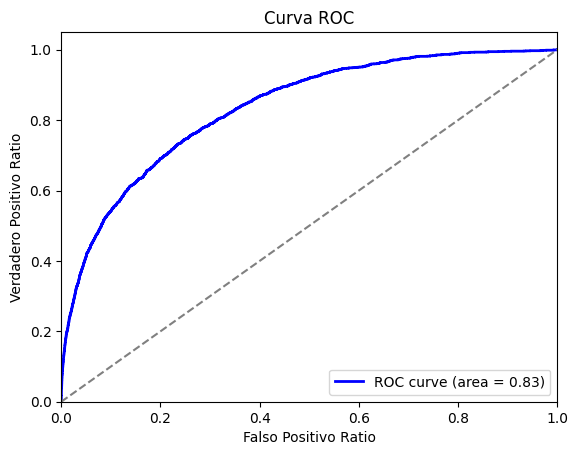

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_true = yv[tgt]
y_scores = modelo_fraude.predict_proba(Xv[varw])[:,1]

# Calcular la curva ROC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure()
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Falso Positivo Ratio")
plt.ylabel("Verdadero Positivo Ratio")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

In [ ]:
def metricas(model,Xv,yv):
    print(" Métricas para modelo de clasificación: \n")

    print(" Valor ROC : %.3f"   %roc_auc_score( y_score=model.predict_proba(Xv)[:,1] , y_true=yv  )   )

    print(" Valor ACC : %.3f\n" %accuracy_score( y_pred=model.predict(Xv) , y_true=yv) )

    print(" Matriz de confusión: ", "\n", confusion_matrix(y_pred=model.predict(Xv) , y_true=yv ) )

In [ ]:
metricas(modelo_fraude , Xv[varw], yv[tgt])

 Métricas para modelo de clasificación: 

 Valor ROC : 0.834
 Valor ACC : 0.994

 Matriz de confusión:  
 [[385658      0]
 [  2178      0]]


# Transformación a Scorecard

In [ ]:
# Para hacer una interpretación / transformación a tarjeta de puntos ( scorecard ) es necesario
# ya tener el modelo

In [ ]:
PDO = 30
base_score = 100
base_odds = 2

factor = PDO / np.log(2)

offset = base_score - factor * np.log( base_odds)

print(f"Factor: {factor}, Offset: {offset}")

betas = modelo_fraude.coef_[0].tolist()
beta0 = modelo_fraude.intercept_[0]

n = len(betas)

Factor: 43.2808512266689, Offset: 70.0


In [ ]:
for v, beta in zip(varw, betas):

    print(f"Variable: {v}, con beta: {beta}")

    Xt[f'pts_{v}'] = np.ceil(  ( -Xt[v] * beta+beta0 / n  ) * factor + offset / n )

    Xv[f'pts_{v}'] = np.ceil(  ( -Xv[v] * beta+beta0 / n  ) * factor + offset / n )

Variable: w_n_c_etapa_del_dia, con beta: -1.029113370960487
Variable: w_n_c_category, con beta: -1.0051193076222218
Variable: w_d_v_prev_trans_count_5, con beta: -0.9370102226768072
Variable: w_d_v_ratio_amt_prev_trans_amt_5, con beta: -1.0414797407947403
Variable: w_n_c_month_desc, con beta: -0.3879558269411282
Variable: w_n_c_month, con beta: -0.3879558269411282
Variable: w_d_v_age_5, con beta: -0.973609873013309
Variable: w_d_v_unix_time_6, con beta: 0.529401682200547
Variable: w_n_c_day, con beta: -0.8962008780277666
Variable: w_n_c_dayofweek_desc, con beta: -0.5411951103727237
Variable: w_n_c_dayofweek, con beta: -0.5411951103727237
Variable: w_n_c_gender, con beta: -0.220502631340003


In [ ]:
# Ejemplo de como se ve la variable con puntos para el scorecard
Xt[['n_c_etapa_del_dia','pts_w_n_c_etapa_del_dia']].drop_duplicates()

,n_c_etapa_del_dia,pts_w_n_c_etapa_del_dia
0,noche,-39
1,madrugada,-37
4,mañana,64
10,tarde,59


In [ ]:
varp = Xt.filter(like='pts').columns.tolist()

In [ ]:
len(varp), varp

(12,
 ['pts_w_n_c_etapa_del_dia',
  'pts_w_n_c_category',
  'pts_w_d_v_prev_trans_count_5',
  'pts_w_d_v_ratio_amt_prev_trans_amt_5',
  'pts_w_n_c_month_desc',
  'pts_w_n_c_month',
  'pts_w_d_v_age_5',
  'pts_w_d_v_unix_time_6',
  'pts_w_n_c_day',
  'pts_w_n_c_dayofweek_desc',
  'pts_w_n_c_dayofweek',
  'pts_w_n_c_gender'])

In [ ]:
Xt['score'] = Xt[varp].sum(axis=1)
Xv['score'] = Xv[varp].sum(axis=1)

<Axes: >

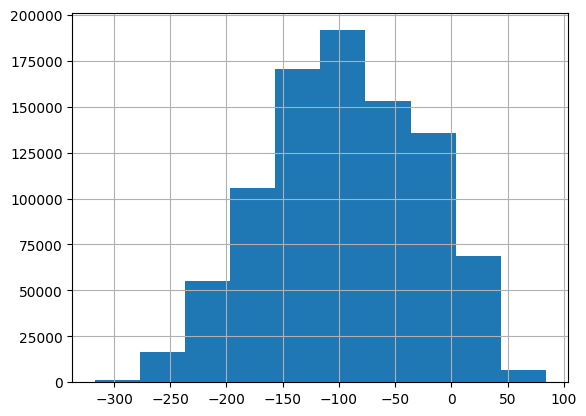

In [ ]:
Xt['score'].hist()

# Scoring

In [ ]:
lst = []

for vi, vp in zip( [v[2:] for v in varw] , varp):
    print(vi , " ----- " , vp)

    aux = Xt[[vi,vp]].drop_duplicates()
    aux = aux.sort_values( by = vi , ascending = True ).reset_index(drop=True)
    aux.columns = ['atributo','puntos']
    aux['característica'] = vi
    lst.append(aux)

n_c_etapa_del_dia  -----  pts_w_n_c_etapa_del_dia
n_c_category  -----  pts_w_n_c_category
d_v_prev_trans_count_5  -----  pts_w_d_v_prev_trans_count_5
d_v_ratio_amt_prev_trans_amt_5  -----  pts_w_d_v_ratio_amt_prev_trans_amt_5
n_c_month_desc  -----  pts_w_n_c_month_desc
n_c_month  -----  pts_w_n_c_month
d_v_age_5  -----  pts_w_d_v_age_5
d_v_unix_time_6  -----  pts_w_d_v_unix_time_6
n_c_day  -----  pts_w_n_c_day
n_c_dayofweek_desc  -----  pts_w_n_c_dayofweek_desc
n_c_dayofweek  -----  pts_w_n_c_dayofweek
n_c_gender  -----  pts_w_n_c_gender


In [ ]:
scorecard = pd.concat(lst,ignore_index=True)

In [ ]:
pd.set_option('display.max_rows', 120)

In [ ]:
scorecard

,atributo,puntos,característica
0,madrugada,-37,n_c_etapa_del_dia
1,mañana,64,n_c_etapa_del_dia
2,noche,-39,n_c_etapa_del_dia
3,tarde,59,n_c_etapa_del_dia
4,entertainment,25,n_c_category
5,food_dining,49,n_c_category
6,gas_transport,0,n_c_category
7,grocery_net,20,n_c_category
8,grocery_pos,-51,n_c_category
9,health_fitness,43,n_c_category


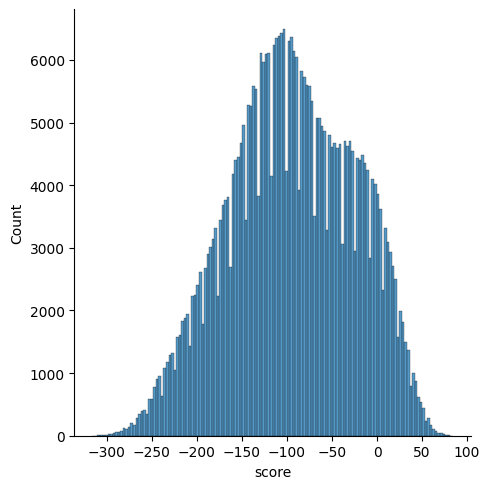

In [ ]:
sns.displot(Xv['score'])

In [ ]:
df_val = Xv.merge(yv, on=um, how='left')

In [ ]:
df_val['is_fraud'].value_counts().reset_index()

,is_fraud,count
0,0,385658
1,1,2178


<Axes: >

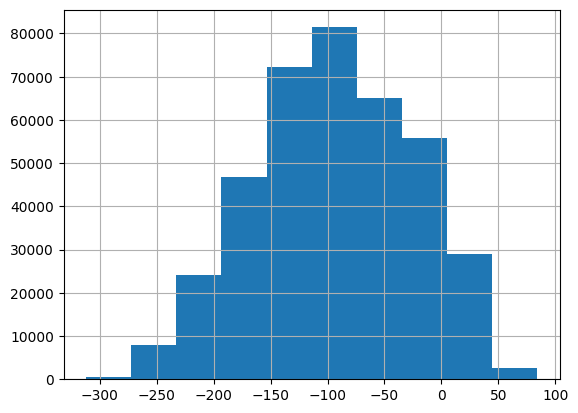

In [ ]:
df_val[df_val['is_fraud']==0]['score'].hist()

<Axes: >

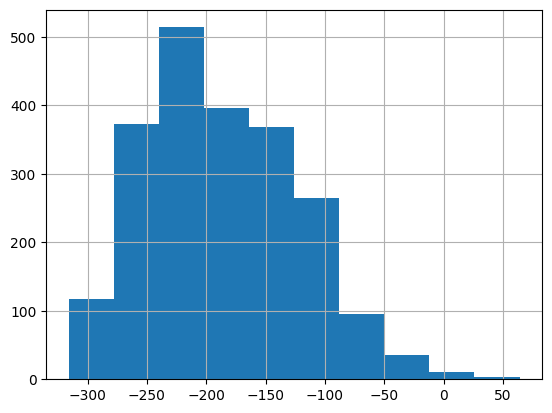

In [ ]:
df_val[df_val['is_fraud']==1]['score'].hist()

<Axes: >

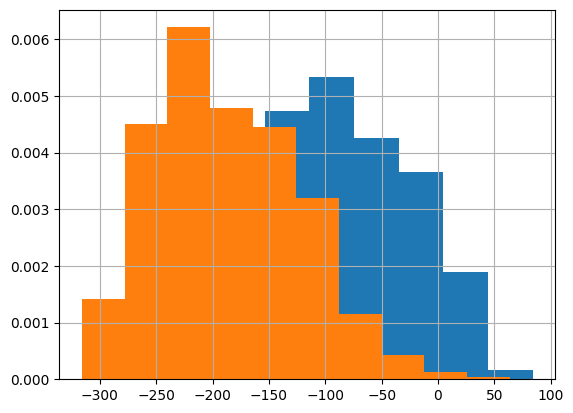

In [ ]:
df_val[df_val['is_fraud']==0]['score'].hist(density=True)
df_val[df_val['is_fraud']==1]['score'].hist(density=True)

In [ ]:
scorecard

,atributo,puntos,característica
0,madrugada,-37,n_c_etapa_del_dia
1,mañana,64,n_c_etapa_del_dia
2,noche,-39,n_c_etapa_del_dia
3,tarde,59,n_c_etapa_del_dia
4,entertainment,25,n_c_category
5,food_dining,49,n_c_category
6,gas_transport,0,n_c_category
7,grocery_net,20,n_c_category
8,grocery_pos,-51,n_c_category
9,health_fitness,43,n_c_category
